 # EfficientNet-B0 Fine-Tuning – ISIC 2018 MEL vs NV

 Binary classification: **MEL** (melanoma) vs **NV** (melanocytic nevi) using the ISIC 2018 Task 3 training set.

 | Detail | Value |
 |---|---|
 | Backbone | EfficientNet-B0 (ImageNet-pretrained) |
 | Input size | 224 × 224 (EfficientNet-B0 default) |
 | Train/Val split | 80 / 20, `random_split` seeded at 42 |
 | Class imbalance | `WeightedRandomSampler` on train split (NV greatly outnumbers MEL) |
 | Checkpointing | Per-epoch, auto-resume from latest `epoch_*.pth` |

In [ ]:
# ── Imports ──────────────────────────────────────────────────────────────────
import os
import sys
import glob
import math

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler, random_split
from torchvision import transforms, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from tqdm import tqdm

parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from datasets import ISIC2018Dataset, TransformDataset

print(f"PyTorch {torch.__version__} | CUDA available: {torch.cuda.is_available()}")

PyTorch 2.10.0+cu128 | CUDA available: True


In [ ]:
# ── Parameters (edit here) ────────────────────────────────────────────────────
DATASET_DIR    = "dataset/ISIC_2018/ISIC2018_Task3_Training_Input"
LABELS_CSV     = "dataset/ISIC_2018/ISIC2018_Task3_Training_GroundTruth.csv"
IMAGE_SIZE     = 224          # EfficientNet-B0 default
BATCH_SIZE     = 16
NUM_WORKERS    = 2
VAL_SPLIT      = 0.2          # fraction held out for validation
LEARNING_RATE  = 1e-4         # lower LR appropriate for fine-tuning
NUM_EPOCHS     = 40
LABEL_SMOOTHING= 0.3          # aggressive label smoothing
CHECKPOINT_DIR = "checkpoints/efficientnet_nv_mel_classifier/run_2"
DEVICE         = "cuda" if torch.cuda.is_available() else "cpu"
LABEL_NAMES    = ["NV", "MEL"]

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f"Using device  : {DEVICE}")
print(f"Image size    : {IMAGE_SIZE} x {IMAGE_SIZE}")
print(f"Checkpoint dir: {os.path.abspath(CHECKPOINT_DIR)}")

Using device  : cuda
Image size    : 224 x 224
Checkpoint dir: /home/tejass_iitp/capstone/checkpoints/efficientnet_nv_mel_classifier/run_2


In [ ]:
# ── Transforms ───────────────────────────────────────────────────────────────
# Train: augmentations to reduce over-fitting on the small MEL class.
# Val  : deterministic centre-crop only.
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],   # ImageNet mean
                         [0.229, 0.224, 0.225]),   # ImageNet std
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

print("Transform pipelines defined.")

Transform pipelines defined.


In [ ]:
# ── Dataset & DataLoaders ─────────────────────────────────────────────────────
# Base dataset with transform=None so it returns raw PIL images.
# TransformDataset wraps each split with its own augmentation pipeline.

full_dataset = ISIC2018Dataset(
    root_dir       = DATASET_DIR,
    transform      = None,
    labels_csv     = LABELS_CSV,
    include_labels = LABEL_NAMES,
)

print(f"Total labeled samples (NV+MEL): {len(full_dataset)}")

# ── Train / Val split ─────────────────────────────────────────────────────────
n_total = len(full_dataset)
n_val   = int(n_total * VAL_SPLIT)
n_train = n_total - n_val

generator = torch.Generator().manual_seed(42)
train_sub, val_sub = random_split(
    full_dataset, [n_train, n_val], generator=generator
)

train_dataset = TransformDataset(train_sub, train_transform)
val_dataset   = TransformDataset(val_sub,   val_transform)

print(f"Train samples : {len(train_dataset):,}")
print(f"Val   samples : {len(val_dataset):,}")

# ── Collect raw one-hot labels for WeightedRandomSampler (no image I/O) ──────
# label_map rows are [NV, MEL]; binary label = argmax
all_labels = [
    int(full_dataset.label_map.loc[
        os.path.splitext(os.path.basename(p))[0]
    ].values.argmax())
    for p in full_dataset.image_paths
]
class_counts = np.bincount(all_labels)
print(f"Class counts  : NV={class_counts[0]:,}  MEL={class_counts[1]:,}")

# ── WeightedRandomSampler on train split only ─────────────────────────────────
train_labels   = [all_labels[i] for i in train_sub.indices]
class_weights  = 1.0 / class_counts
sample_weights = [class_weights[lbl] for lbl in train_labels]
train_sampler  = WeightedRandomSampler(
    weights     = torch.DoubleTensor(sample_weights),
    num_samples = len(train_dataset),
    replacement = True,
)

train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    sampler     = train_sampler,
    num_workers = NUM_WORKERS,
    pin_memory  = DEVICE == "cuda",
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = DEVICE == "cuda",
)

print(f"Train batches/epoch : {len(train_loader)}")
print(f"Val   batches/epoch : {len(val_loader)}")

Found 10015 valid JPEG images in 'dataset/ISIC_2018/ISIC2018_Task3_Training_Input'
Total labeled samples (NV+MEL): 10015
Train samples : 8,012
Val   samples : 2,003
Class counts  : NV=8,902  MEL=1,113
Train batches/epoch : 501
Val   batches/epoch : 126


Batch shape : torch.Size([16, 3, 224, 224])
Labels (raw): [[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [0.0, 1.0], [0.0, 1.0], [1.0, 0.0], [0.0, 1.0], [1.0, 0.0]]


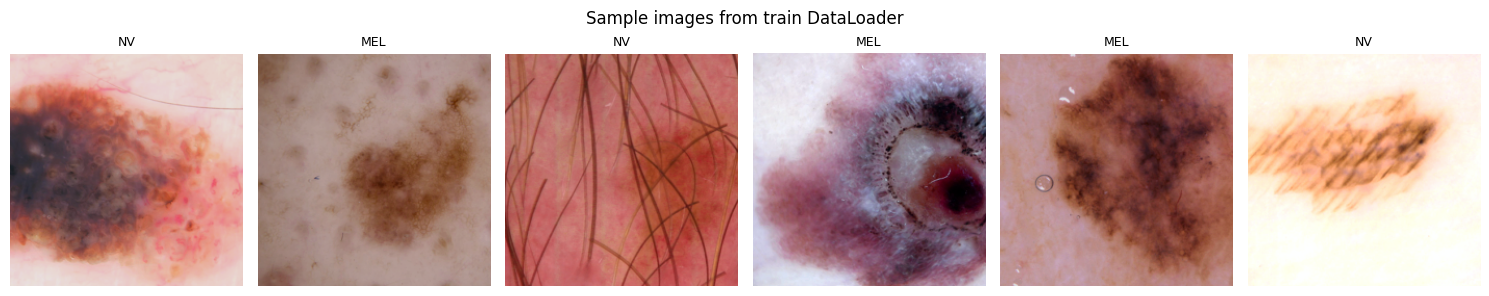

In [ ]:
# ── Sanity check: visualise a batch ──────────────────────────────────────────
sample_imgs, sample_labels = next(iter(train_loader))
print("Batch shape :", sample_imgs.shape)
print("Labels (raw):", sample_labels[:8].tolist())

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
for i, ax in enumerate(axes):
    img = sample_imgs[i].permute(1, 2, 0).numpy()
    img = (img * std + mean).clip(0, 1)
    cls = sample_labels[i].argmax().item()
    ax.imshow(img)
    ax.set_title(LABEL_NAMES[cls], fontsize=9)
    ax.axis("off")
plt.suptitle("Sample images from train DataLoader", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# ── Model – EfficientNet-B0 with partial freezing ────────────────────────────
#
# EfficientNet-B0 feature extractor layout (model.features):
#   [0]  Conv2dNormActivation  – stem (32 filters)
#   [1]  Sequential            – MBConv block stage 1
#   [2]  Sequential            – MBConv block stage 2
#   [3]  Sequential            – MBConv block stage 3
#   [4]  Sequential            – MBConv block stage 4
#   [5]  Sequential            – MBConv block stage 5
#   [6]  Sequential            – MBConv block stage 6
#   [7]  Sequential            – MBConv block stage 7
#   [8]  Conv2dNormActivation  – head conv

backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

FREEZE_UP_TO = 0 # count includes stem
for i in range(FREEZE_UP_TO):
    for param in backbone.features[i].parameters():
        param.requires_grad = False

# Replace the classifier head: 1280-d → 1 (NV/MEL)
in_features = backbone.classifier[1].in_features
backbone.classifier = nn.Sequential(
    nn.Dropout(p=0.4, inplace=True),
    nn.Linear(in_features, 1),
)

model = backbone.to(DEVICE)

frozen   = sum(p.numel() for p in model.parameters() if not p.requires_grad)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Frozen parameters   : {frozen:,}")
print(f"Trainable parameters: {trainable:,}")

Frozen parameters   : 0
Trainable parameters: 4,008,829


In [ ]:
# ── Loss / optimiser / scheduler + auto-resume ────────────────────────────────
criterion = nn.BCEWithLogitsLoss()
# Only pass parameters that require gradients to the optimiser
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

# ── History buffers ───────────────────────────────────────────────────────────
train_losses     = []
val_losses       = []
val_aucs         = []
val_conf_matrices= []
val_accuracies   = []
val_precisions   = []
val_recalls      = []
val_f1s          = []
start_epoch      = 1

# ── Resume from latest checkpoint if one exists ───────────────────────────────
existing = sorted(glob.glob(os.path.join(CHECKPOINT_DIR, "epoch_*.pth")))
if existing:
    latest = existing[-1]
    ckpt   = torch.load(latest, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optim_state"])
    scheduler.load_state_dict(ckpt["sched_state"])
    start_epoch      = ckpt["epoch"] + 1
    train_losses     = ckpt.get("train_losses", [])
    val_losses       = ckpt.get("val_losses", [])
    val_aucs         = ckpt.get("val_aucs", [])
    val_conf_matrices= ckpt.get("val_conf_matrices", [])
    val_accuracies   = ckpt.get("val_accuracies", [])
    val_precisions   = ckpt.get("val_precisions", [])
    val_recalls      = ckpt.get("val_recalls", [])
    val_f1s          = ckpt.get("val_f1s", [])
    print(f"Resumed from '{latest}' (epoch {ckpt['epoch']} of {NUM_EPOCHS})")
else:
    print("No checkpoint found – starting from scratch.")

if start_epoch > NUM_EPOCHS:
    print(f"Training already complete ({NUM_EPOCHS} epochs done). Nothing to do.")

Resumed from 'checkpoints/efficientnet_nv_mel_classifier/run_2/epoch_020.pth' (epoch 20 of 40)


In [ ]:
# ── Training loop (checkpoints every epoch) ───────────────────────────────────
for epoch in range(start_epoch, NUM_EPOCHS + 1):

    # ── Train ─────────────────────────────────────────────────────────────────
    model.train()
    running_loss = 0.0
    total        = 0

    pbar = tqdm(train_loader, desc=f"Epoch [{epoch:>3}/{NUM_EPOCHS}] train", leave=False)
    for imgs, labels_onehot in pbar:
        imgs          = imgs.to(DEVICE, non_blocking=True)
        labels_onehot = labels_onehot.to(DEVICE, non_blocking=True)
        labels        = labels_onehot.argmax(dim=1).float()

        # Apply aggressive label smoothing
        smoothed_labels = labels * (1.0 - LABEL_SMOOTHING) + 0.5 * LABEL_SMOOTHING

        logits = model(imgs).squeeze(-1)
        loss   = criterion(logits, smoothed_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        total        += imgs.size(0)
        pbar.set_postfix(loss=f"{running_loss / total:.4f}")

    train_loss = running_loss / total
    train_losses.append(train_loss)

    # ── Validate ──────────────────────────────────────────────────────────────
    model.eval()
    val_running_loss = 0.0
    val_total        = 0
    all_logits       = []
    all_targets      = []   # ground-truth class indices

    with torch.no_grad():
        for imgs, labels_onehot in tqdm(val_loader, desc=f"Epoch [{epoch:>3}/{NUM_EPOCHS}] val  ", leave=False):
            imgs          = imgs.to(DEVICE, non_blocking=True)
            labels_onehot = labels_onehot.to(DEVICE, non_blocking=True)
            labels        = labels_onehot.argmax(dim=1)

            logits = model(imgs).squeeze(-1)
            loss   = criterion(logits, labels.float())
            val_running_loss += loss.item() * imgs.size(0)
            val_total        += imgs.size(0)

            all_logits.extend(logits.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    val_loss = val_running_loss / val_total
    
    all_preds = (np.array(all_logits) > 0).astype(int)
    val_auc  = roc_auc_score(all_targets, all_logits)
    val_acc  = accuracy_score(all_targets, all_preds)
    val_prec = precision_score(all_targets, all_preds, zero_division=0)
    val_rec  = recall_score(all_targets, all_preds, zero_division=0)
    val_f1   = f1_score(all_targets, all_preds, zero_division=0)
    val_cm   = confusion_matrix(all_targets, all_preds)

    val_losses.append(val_loss)
    val_aucs.append(val_auc)
    val_accuracies.append(val_acc)
    val_precisions.append(val_prec)
    val_recalls.append(val_rec)
    val_f1s.append(val_f1)
    val_conf_matrices.append(val_cm)

    scheduler.step(val_loss)

    print(
        f"Epoch [{epoch:>3}/{NUM_EPOCHS}]\n"
        f"  Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.2e}\n"
        f"  Val AUC: {val_auc:.4f} | Acc: {val_acc:.4f} | Prec: {val_prec:.4f} | Rec: {val_rec:.4f} | F1: {val_f1:.4f}\n"
        f"  Confusion Matrix:\n{val_cm}"
    )

    # ── Save per-epoch checkpoint ──────────────────────────────────────────────
    ckpt_path = os.path.join(CHECKPOINT_DIR, f"epoch_{epoch:03d}.pth")
    torch.save({
        "epoch"       : epoch,
        "model_state" : model.state_dict(),
        "optim_state" : optimizer.state_dict(),
        "sched_state" : scheduler.state_dict(),
        "config": {
            "image_size"    : IMAGE_SIZE,
            "freeze_up_to"  : FREEZE_UP_TO,
            "num_classes"   : 2,
            "val_split"     : VAL_SPLIT,
            "label_smoothing": LABEL_SMOOTHING,
        },
        "train_losses"     : train_losses,
        "val_losses"       : val_losses,
        "val_aucs"         : val_aucs,
        "val_conf_matrices": val_conf_matrices,
        "val_accuracies"   : val_accuracies,
        "val_precisions"   : val_precisions,
        "val_recalls"      : val_recalls,
        "val_f1s"          : val_f1s,
    }, ckpt_path)
    print(f"  └─ Checkpoint saved: {ckpt_path}")

print("\nTraining complete.")

Epoch [ 21/40]
  Train Loss: 0.4393 | Val Loss: 0.2402 | LR: 1.25e-05
  Val AUC: 0.9229 | Acc: 0.9501 | Prec: 0.8316 | Rec: 0.6991 | F1: 0.7596
  Confusion Matrix:
[[1745   32]
 [  68  158]]
  └─ Checkpoint saved: checkpoints/efficientnet_nv_mel_classifier/run_2/epoch_021.pth


Epoch [ 22/40]
  Train Loss: 0.4381 | Val Loss: 0.2399 | LR: 1.25e-05
  Val AUC: 0.9203 | Acc: 0.9506 | Prec: 0.8508 | Rec: 0.6814 | F1: 0.7568
  Confusion Matrix:
[[1750   27]
 [  72  154]]
  └─ Checkpoint saved: checkpoints/efficientnet_nv_mel_classifier/run_2/epoch_022.pth


Epoch [ 23/40]
  Train Loss: 0.4372 | Val Loss: 0.2393 | LR: 1.25e-05
  Val AUC: 0.9168 | Acc: 0.9501 | Prec: 0.8316 | Rec: 0.6991 | F1: 0.7596
  Confusion Matrix:
[[1745   32]
 [  68  158]]
  └─ Checkpoint saved: checkpoints/efficientnet_nv_mel_classifier/run_2/epoch_023.pth


Epoch [ 24/40]
  Train Loss: 0.4368 | Val Loss: 0.2397 | LR: 6.25e-06
  Val AUC: 0.9286 | Acc: 0.9511 | Prec: 0.8556 | Rec: 0.6814 | F1: 0.7586
  Confusion Matrix:
[[1751   26]
 [  72  154]]
  └─ Checkpoint saved: checkpoints/efficientnet_nv_mel_classifier/run_2/epoch_024.pth


Epoch [ 25/40]
  Train Loss: 0.4368 | Val Loss: 0.2380 | LR: 6.25e-06
  Val AUC: 0.9269 | Acc: 0.9526 | Prec: 0.8701 | Rec: 0.6814 | F1: 0.7643
  Confusion Matrix:
[[1754   23]
 [  72  154]]
  └─ Checkpoint saved: checkpoints/efficientnet_nv_mel_classifier/run_2/epoch_025.pth


...

Epoch [ 36/40]
  Train Loss: 0.4332 | Val Loss: 0.2404 | LR: 1.56e-06
  Val AUC: 0.9172 | Acc: 0.9491 | Prec: 0.8163 | Rec: 0.7080 | F1: 0.7583
  Confusion Matrix:
[[1741   36]
 [  66  160]]
  └─ Checkpoint saved: checkpoints/efficientnet_nv_mel_classifier/run_2/epoch_036.pth


Epoch [ 37/40]
  Train Loss: 0.4342 | Val Loss: 0.2416 | LR: 1.56e-06
  Val AUC: 0.9159 | Acc: 0.9506 | Prec: 0.8671 | Rec: 0.6637 | F1: 0.7519
  Confusion Matrix:
[[1754   23]
 [  76  150]]
  └─ Checkpoint saved: checkpoints/efficientnet_nv_mel_classifier/run_2/epoch_037.pth


Epoch [ 38/40]
  Train Loss: 0.4358 | Val Loss: 0.2373 | LR: 7.81e-07
  Val AUC: 0.9203 | Acc: 0.9506 | Prec: 0.8470 | Rec: 0.6858 | F1: 0.7579
  Confusion Matrix:
[[1749   28]
 [  71  155]]
  └─ Checkpoint saved: checkpoints/efficientnet_nv_mel_classifier/run_2/epoch_038.pth


Epoch [ 39/40]
  Train Loss: 0.4364 | Val Loss: 0.2325 | LR: 7.81e-07
  Val AUC: 0.9259 | Acc: 0.9516 | Prec: 0.8862 | Rec: 0.6549 | F1: 0.7532
  Confusion Matrix:
[[1758   19]
 [  78  148]]
  └─ Checkpoint saved: checkpoints/efficientnet_nv_mel_classifier/run_2/epoch_039.pth


Epoch [ 40/40]
  Train Loss: 0.4330 | Val Loss: 0.2395 | LR: 7.81e-07
  Val AUC: 0.9342 | Acc: 0.9501 | Prec: 0.8387 | Rec: 0.6903 | F1: 0.7573
  Confusion Matrix:
[[1747   30]
 [  70  156]]
  └─ Checkpoint saved: checkpoints/efficientnet_nv_mel_classifier/run_2/epoch_040.pth

Training complete.


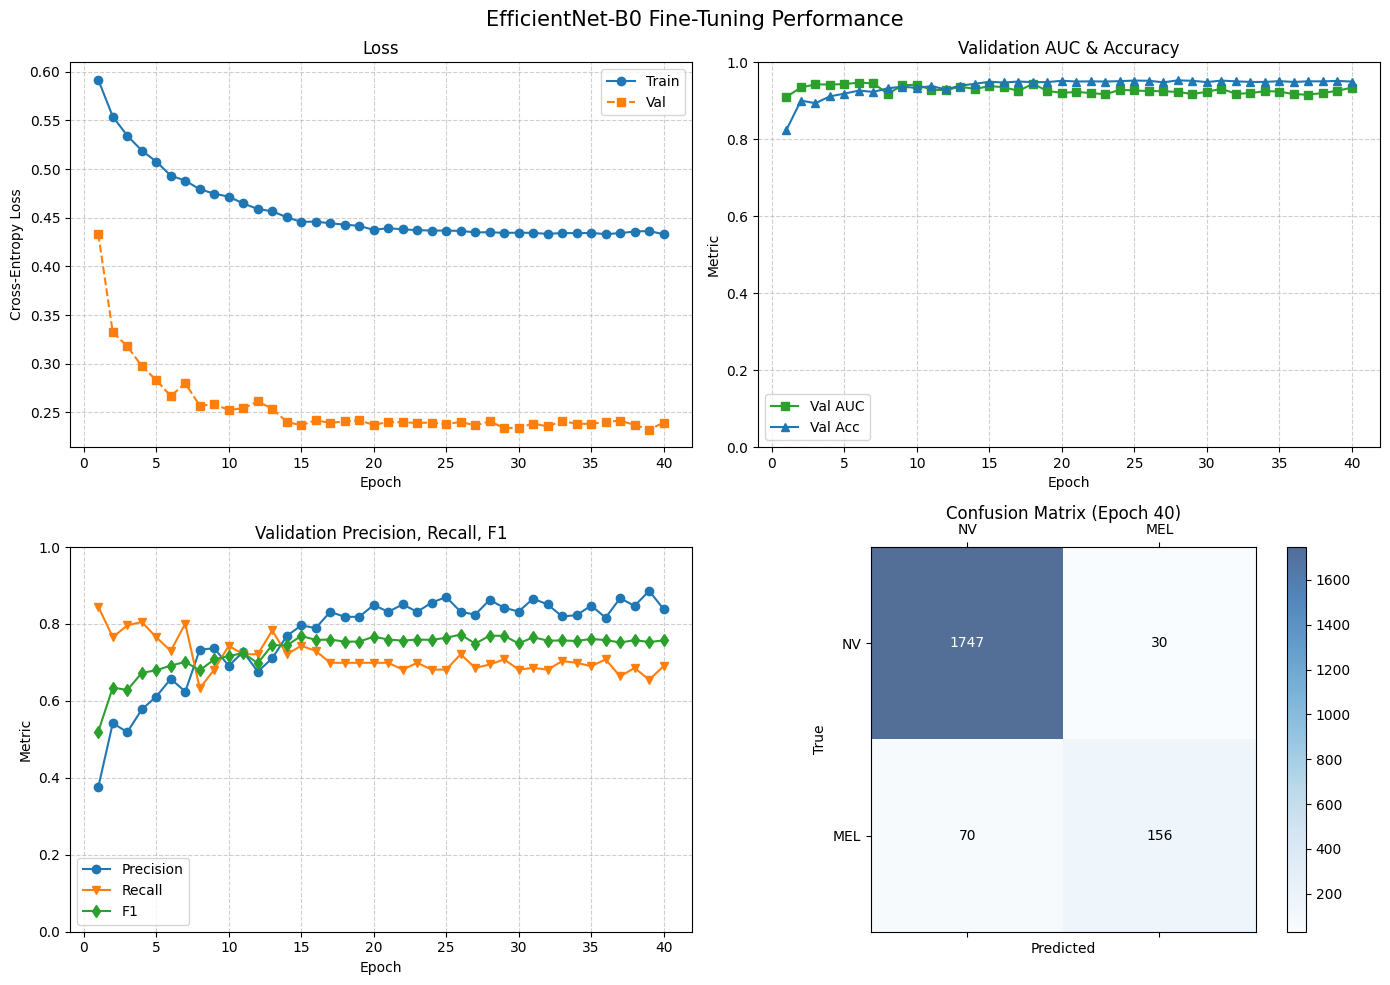

In [ ]:
# ── Training curves ───────────────────────────────────────────────────────────
n_recorded = len(train_losses)
epochs_x   = range(1, n_recorded + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss
axes[0, 0].plot(epochs_x, train_losses, marker="o", linewidth=1.5, label="Train")
axes[0, 0].plot(epochs_x, val_losses,   marker="s", linewidth=1.5, label="Val", linestyle="--")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Cross-Entropy Loss")
axes[0, 0].set_title("Loss")
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle="--", alpha=0.6)

# 2. AUC & Accuracy
axes[0, 1].plot(epochs_x, val_aucs, marker="s", linewidth=1.5, color="tab:green", label="Val AUC")
axes[0, 1].plot(epochs_x, val_accuracies, marker="^", linewidth=1.5, color="tab:blue", label="Val Acc")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Metric")
axes[0, 1].set_ylim(0, 1)
axes[0, 1].set_title("Validation AUC & Accuracy")
axes[0, 1].legend()
axes[0, 1].grid(True, linestyle="--", alpha=0.6)

# 3. Precision, Recall, F1
axes[1, 0].plot(epochs_x, val_precisions, marker="o", linewidth=1.5, label="Precision")
axes[1, 0].plot(epochs_x, val_recalls, marker="v", linewidth=1.5, label="Recall")
axes[1, 0].plot(epochs_x, val_f1s, marker="d", linewidth=1.5, label="F1")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Metric")
axes[1, 0].set_ylim(0, 1)
axes[1, 0].set_title("Validation Precision, Recall, F1")
axes[1, 0].legend()
axes[1, 0].grid(True, linestyle="--", alpha=0.6)

# 4. Final Epoch Confusion Matrix
if n_recorded > 0:
    cm = val_conf_matrices[-1]
    cax = axes[1, 1].matshow(cm, cmap="Blues", alpha=0.7)
    fig.colorbar(cax, ax=axes[1, 1])
    for (i, j), z in np.ndenumerate(cm):
        axes[1, 1].text(j, i, f'{z}', ha='center', va='center',
                        color='white' if cm[i, j] > cm.max() / 2 else 'black')
    axes[1, 1].set_xticks([0, 1])
    axes[1, 1].set_yticks([0, 1])
    axes[1, 1].set_xticklabels(LABEL_NAMES)
    axes[1, 1].set_yticklabels(LABEL_NAMES)
    axes[1, 1].set_xlabel("Predicted")
    axes[1, 1].set_ylabel("True")
    axes[1, 1].set_title(f"Confusion Matrix (Epoch {n_recorded})", pad=20)
else:
    axes[1, 1].axis('off')

plt.suptitle("EfficientNet-B0 Fine-Tuning Performance", fontsize=15)
plt.tight_layout()
plt.show()

In [ ]:
# ── Collect Activation Distributions ─────────────────────────────────────────
existing = sorted(glob.glob(os.path.join(CHECKPOINT_DIR, "epoch_*.pth")))
all_probs = []
ckpts = []

if existing:
    model.eval()
    with torch.no_grad():
        for ckpt_path in existing:
            ckpt_num = int(os.path.basename(ckpt_path).split('_')[1].split('.')[0])
            ckpts.append(ckpt_num)
            
            # Load checkpoint
            ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
            model.load_state_dict(ckpt["model_state"])
            
            ckpt_probs = []
            batch_idx = 0
            for images, labels in tqdm(val_loader, desc=f"Checkpoint {ckpt_num:03d}", leave=False):
                if batch_idx >= 10: # ONLY FIRST 10 FOR NOW!!!
                    break

                images = images.to(DEVICE)
                outputs = model(images)
                # Get sigmoid probabilities
                probs = torch.sigmoid(outputs).cpu().numpy()
                ckpt_probs.extend(probs.flatten())

                batch_idx += 1
            
            all_probs.append(ckpt_probs)
    print(f"Collected distributions for {len(all_probs)} checkpoints.")
else:
    print("No checkpoints found in " + CHECKPOINT_DIR)

Collected distributions for 40 checkpoints.


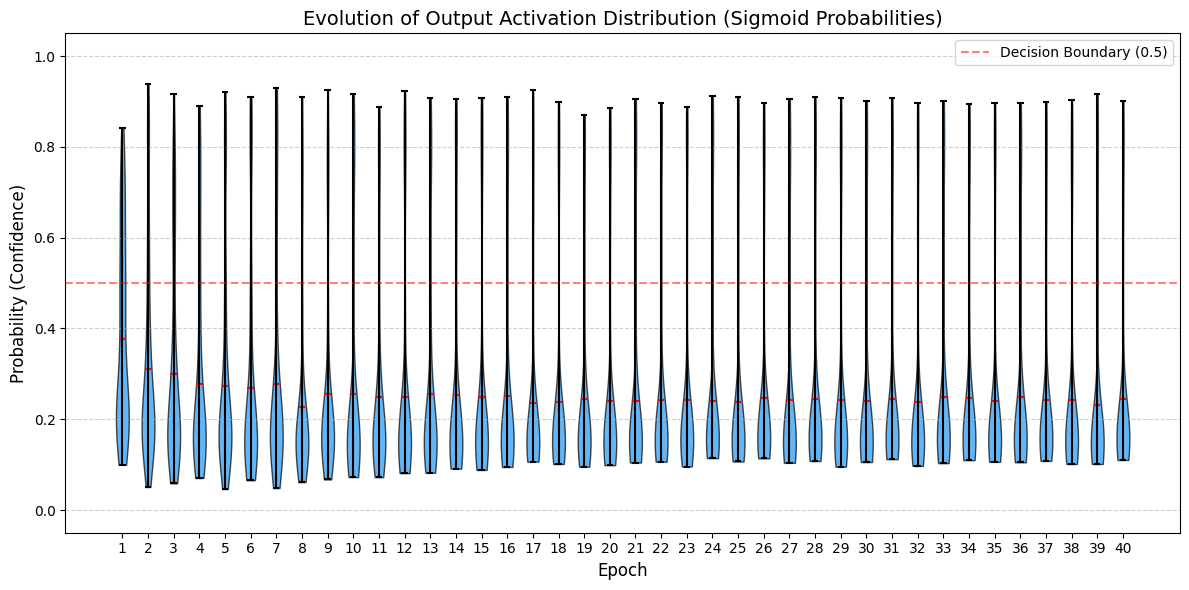

In [ ]:
# ── Plot Distributions ────────────────────────────────────────────────────────
plt.figure(figsize=(12, 6))

# Create violin plot
parts = plt.violinplot(all_probs, positions=ckpts, showmeans=True, showmedians=False)

# Customize aesthetics
for pc in parts['bodies']:
    pc.set_facecolor('#2196F3')
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)

parts['cbars'].set_edgecolor('black')
parts['cmaxes'].set_edgecolor('black')
parts['cmins'].set_edgecolor('black')
parts['cmeans'].set_edgecolor('red')

plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Decision Boundary (0.5)')

plt.title("Evolution of Output Activation Distribution (Sigmoid Probabilities)", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Probability (Confidence)", fontsize=12)
plt.xticks(ckpts)
plt.ylim(-0.05, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

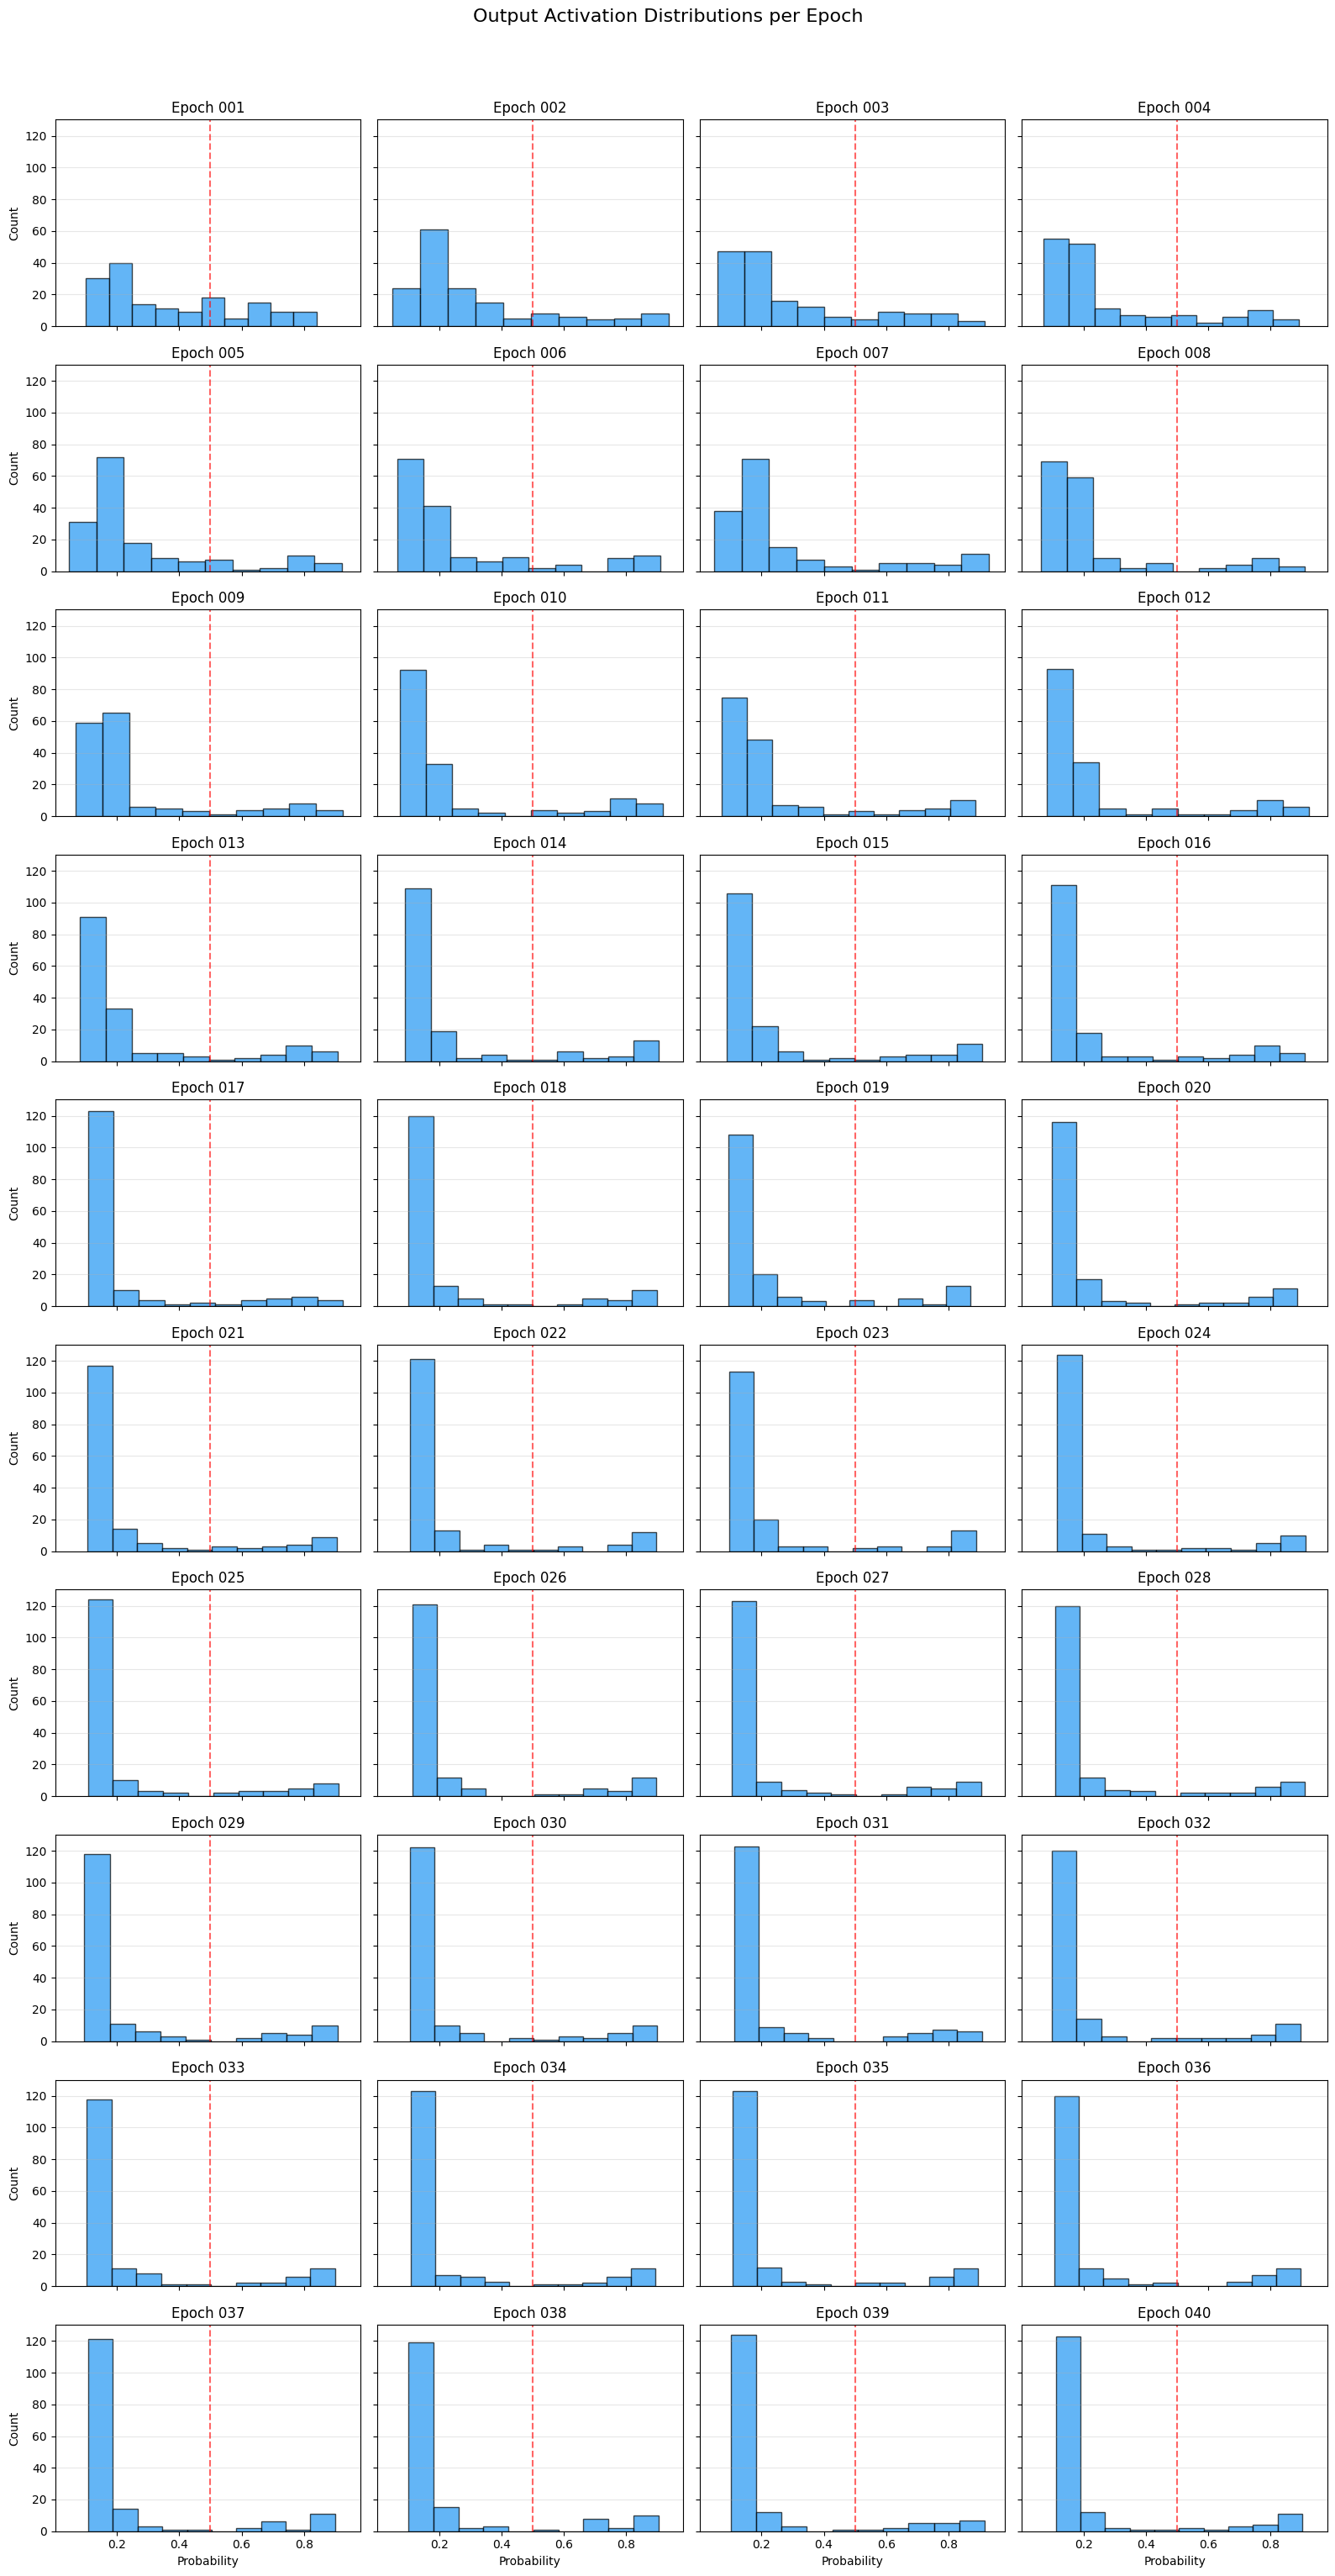

In [ ]:
# ── Plot Distributions (Histograms) ──────────────────────────────────────────
if all_probs:
    n_ckpts = len(all_probs)
    cols = 4
    rows = math.ceil(n_ckpts / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(16, 3 * rows), sharex=True, sharey=True)
    axes = axes.flatten()
    
    for i, (probs, epoch) in enumerate(zip(all_probs, ckpts)):
        ax = axes[i]
        ax.hist(probs, bins=10, color='#2196F3', alpha=0.7, edgecolor='black')
        ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.6)
        ax.set_title(f"Epoch {epoch:03d}")
        ax.grid(axis='y', alpha=0.3)
        
        if i >= (rows - 1) * cols:
            ax.set_xlabel("Probability")
        if i % cols == 0:
            ax.set_ylabel("Count")

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.suptitle("Output Activation Distributions per Epoch", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No data to plot.")